
# Breast Cancer Patient Profiling
## Production-Ready Machine Learning Workflow

**Domain:** Healthcare AI | Oncology Diagnostics  
**Learning Type:** Unsupervised + Supervised Machine Learning  
**Dataset:** Breast Cancer Wisconsin (UCI / scikit-learn)  
**Methods:** PCA · K-Means · Logistic Regression · Random Forest · XGBoost  
**Tools:** Python · scikit-learn · XGBoost · SHAP · FastAPI · Streamlit

In [1]:
!pip install ucimlrepo

In [2]:
import pandas as pandas
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split

from sklearn.cluster import KMeans

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (classification_report,
                            confusion_matrix,
                            roc_auc_score)

from ucimlrepo import fetch_ucirepo

print("All libraries imported successfully")



All libraries imported successfully


 Problem Definition

 
Breast cancer diagnosis currently reduces rich quantitative biopsy
data into a single binary label malignant or benign. This loses
valuable information about patient sub-groups that may respond
differently to treatment.

 Objective
Discover hidden patient groups using unsupervised learning then build a supervised classification model to predict cluster membership for new patients  creating an interpretable patient profiling system.

 Research Question
> "Can unsupervised machine learning surface clinically meaningful
> patient profiles from breast cancer diagnostic data without
> using diagnostic labels during learning?"



In [3]:
# Load dataset
breast_cancer = fetch_ucirepo(id=17)

X = breast_cancer.data.features
y = breast_cancer.data.targets

print("Dataset loaded successfully.")
print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFeature names:\n{list(X.columns)}")

Dataset loaded successfully.
Features shape: (569, 30)
Target shape: (569, 1)

Feature names:
['radius1', 'texture1', 'perimeter1', 'area1', 'smoothness1', 'compactness1', 'concavity1', 'concave_points1', 'symmetry1', 'fractal_dimension1', 'radius2', 'texture2', 'perimeter2', 'area2', 'smoothness2', 'compactness2', 'concavity2', 'concave_points2', 'symmetry2', 'fractal_dimension2', 'radius3', 'texture3', 'perimeter3', 'area3', 'smoothness3', 'compactness3', 'concavity3', 'concave_points3', 'symmetry3', 'fractal_dimension3']


In [4]:
print("Data Shape:", X.shape)


Data Shape: (569, 30)


In [5]:
print("Data Types:", X.dtypes)

Data Types: radius1               float64
texture1              float64
perimeter1            float64
area1                 float64
smoothness1           float64
compactness1          float64
concavity1            float64
concave_points1       float64
symmetry1             float64
fractal_dimension1    float64
radius2               float64
texture2              float64
perimeter2            float64
area2                 float64
smoothness2           float64
compactness2          float64
concavity2            float64
concave_points2       float64
symmetry2             float64
fractal_dimension2    float64
radius3               float64
texture3              float64
perimeter3            float64
area3                 float64
smoothness3           float64
compactness3          float64
concavity3            float64
concave_points3       float64
symmetry3             float64
fractal_dimension3    float64
dtype: object


In [6]:
print(f"Missing Values: {X.isnull().sum()}")

Missing Values: radius1               0
texture1              0
perimeter1            0
area1                 0
smoothness1           0
compactness1          0
concavity1            0
concave_points1       0
symmetry1             0
fractal_dimension1    0
radius2               0
texture2              0
perimeter2            0
area2                 0
smoothness2           0
compactness2          0
concavity2            0
concave_points2       0
symmetry2             0
fractal_dimension2    0
radius3               0
texture3              0
perimeter3            0
area3                 0
smoothness3           0
compactness3          0
concavity3            0
concave_points3       0
symmetry3             0
fractal_dimension3    0
dtype: int64


In [7]:
print(F"No of Duplicates: {X.duplicated().sum()}")

No of Duplicates: 0


In [8]:
X.describe().round(2)

,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,fractal_dimension1,...,radius3,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3
count,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,...,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00
mean,14.13,19.29,91.97,654.89,0.10,0.10,0.09,0.05,0.18,0.06,...,16.27,25.68,107.26,880.58,0.13,0.25,0.27,0.11,0.29,0.08
std,3.52,4.30,24.30,351.91,0.01,0.05,0.08,0.04,0.03,0.01,...,4.83,6.15,33.60,569.36,0.02,0.16,0.21,0.07,0.06,0.02
min,6.98,9.71,43.79,143.50,0.05,0.02,0.00,0.00,0.11,0.05,...,7.93,12.02,50.41,185.20,0.07,0.03,0.00,0.00,0.16,0.06
25%,11.70,16.17,75.17,420.30,0.09,0.06,0.03,0.02,0.16,0.06,...,13.01,21.08,84.11,515.30,0.12,0.15,0.11,0.06,0.25,0.07
50%,13.37,18.84,86.24,551.10,0.10,0.09,0.06,0.03,0.18,0.06,...,14.97,25.41,97.66,686.50,0.13,0.21,0.23,0.10,0.28,0.08
75%,15.78,21.80,104.10,782.70,0.11,0.13,0.13,0.07,0.20,0.07,...,18.79,29.72,125.40,1084.00,0.15,0.34,0.38,0.16,0.32,0.09
max,28.11,39.28,188.50,2501.00,0.16,0.35,0.43,0.20,0.30,0.10,...,36.04,49.54,251.20,4254.00,0.22,1.06,1.25,0.29,0.66,0.21


In [9]:

print("DATA QUALITY SUMMARY")

print(f"Total patients:       {X.shape[0]}")
print(f"Total features:       {X.shape[1]}")
print(f"Missing values:       {X.isnull().sum().sum()}")
print(f"Duplicated rows:      {X.duplicated().sum()}")
print(f"Numeric features:     {X.select_dtypes(include='number').shape[1]}")
print(f"Categorical features: {X.select_dtypes(include='object').shape[1]}")
print(f"Diagnosis counts:")
print(y['Diagnosis'].value_counts())


DATA QUALITY SUMMARY
Total patients:       569
Total features:       30
Missing values:       0
Duplicated rows:      0
Numeric features:     30
Categorical features: 0
Diagnosis counts:
Diagnosis
B    357
M    212
Name: count, dtype: int64


### Data Quality Summary

| Check | Result |
|---|---|
| Total patients | 569 |
| Total features | 30 |
| Missing values | 0 |
| Duplicated rows | 0 |
| Numeric features | 30 |
| Categorical features | 0 |
| Benign patients | 357 (62.7%) |
| Malignant patients | 212 (37.3%) |

**Conclusion:** Dataset is clean and requires minimal preprocessing.

All 30 features are numeric  no encoding required.
Diagnosis column set aside for post-clustering validation only.

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y)


print("TRAIN/TEST SPLIT SUMMARY")

print(f"Training set:  {X_train.shape}")
print(f"Testing set:   {X_test.shape}")
print(f"\nTraining diagnosis distribution:")
print(y_train['Diagnosis'].value_counts())
print(f"\nTesting diagnosis distribution:")
print(y_test['Diagnosis'].value_counts())


TRAIN/TEST SPLIT SUMMARY
Training set:  (455, 30)
Testing set:   (114, 30)

Training diagnosis distribution:
Diagnosis
B    285
M    170
Name: count, dtype: int64

Testing diagnosis distribution:
Diagnosis
B    72
M    42
Name: count, dtype: int64


Train/Test Split Summary

| Set | Benign | Malignant | Total |
|---|---|---|---|
| Training (80%) | 285 | 170 | 455 |
| Testing (20%) | 72 | 42 | 114 |

- Stratified split maintains class proportions in both sets
- Test set locked until final evaluation
- All EDA, preprocessing, and clustering performed on training data only

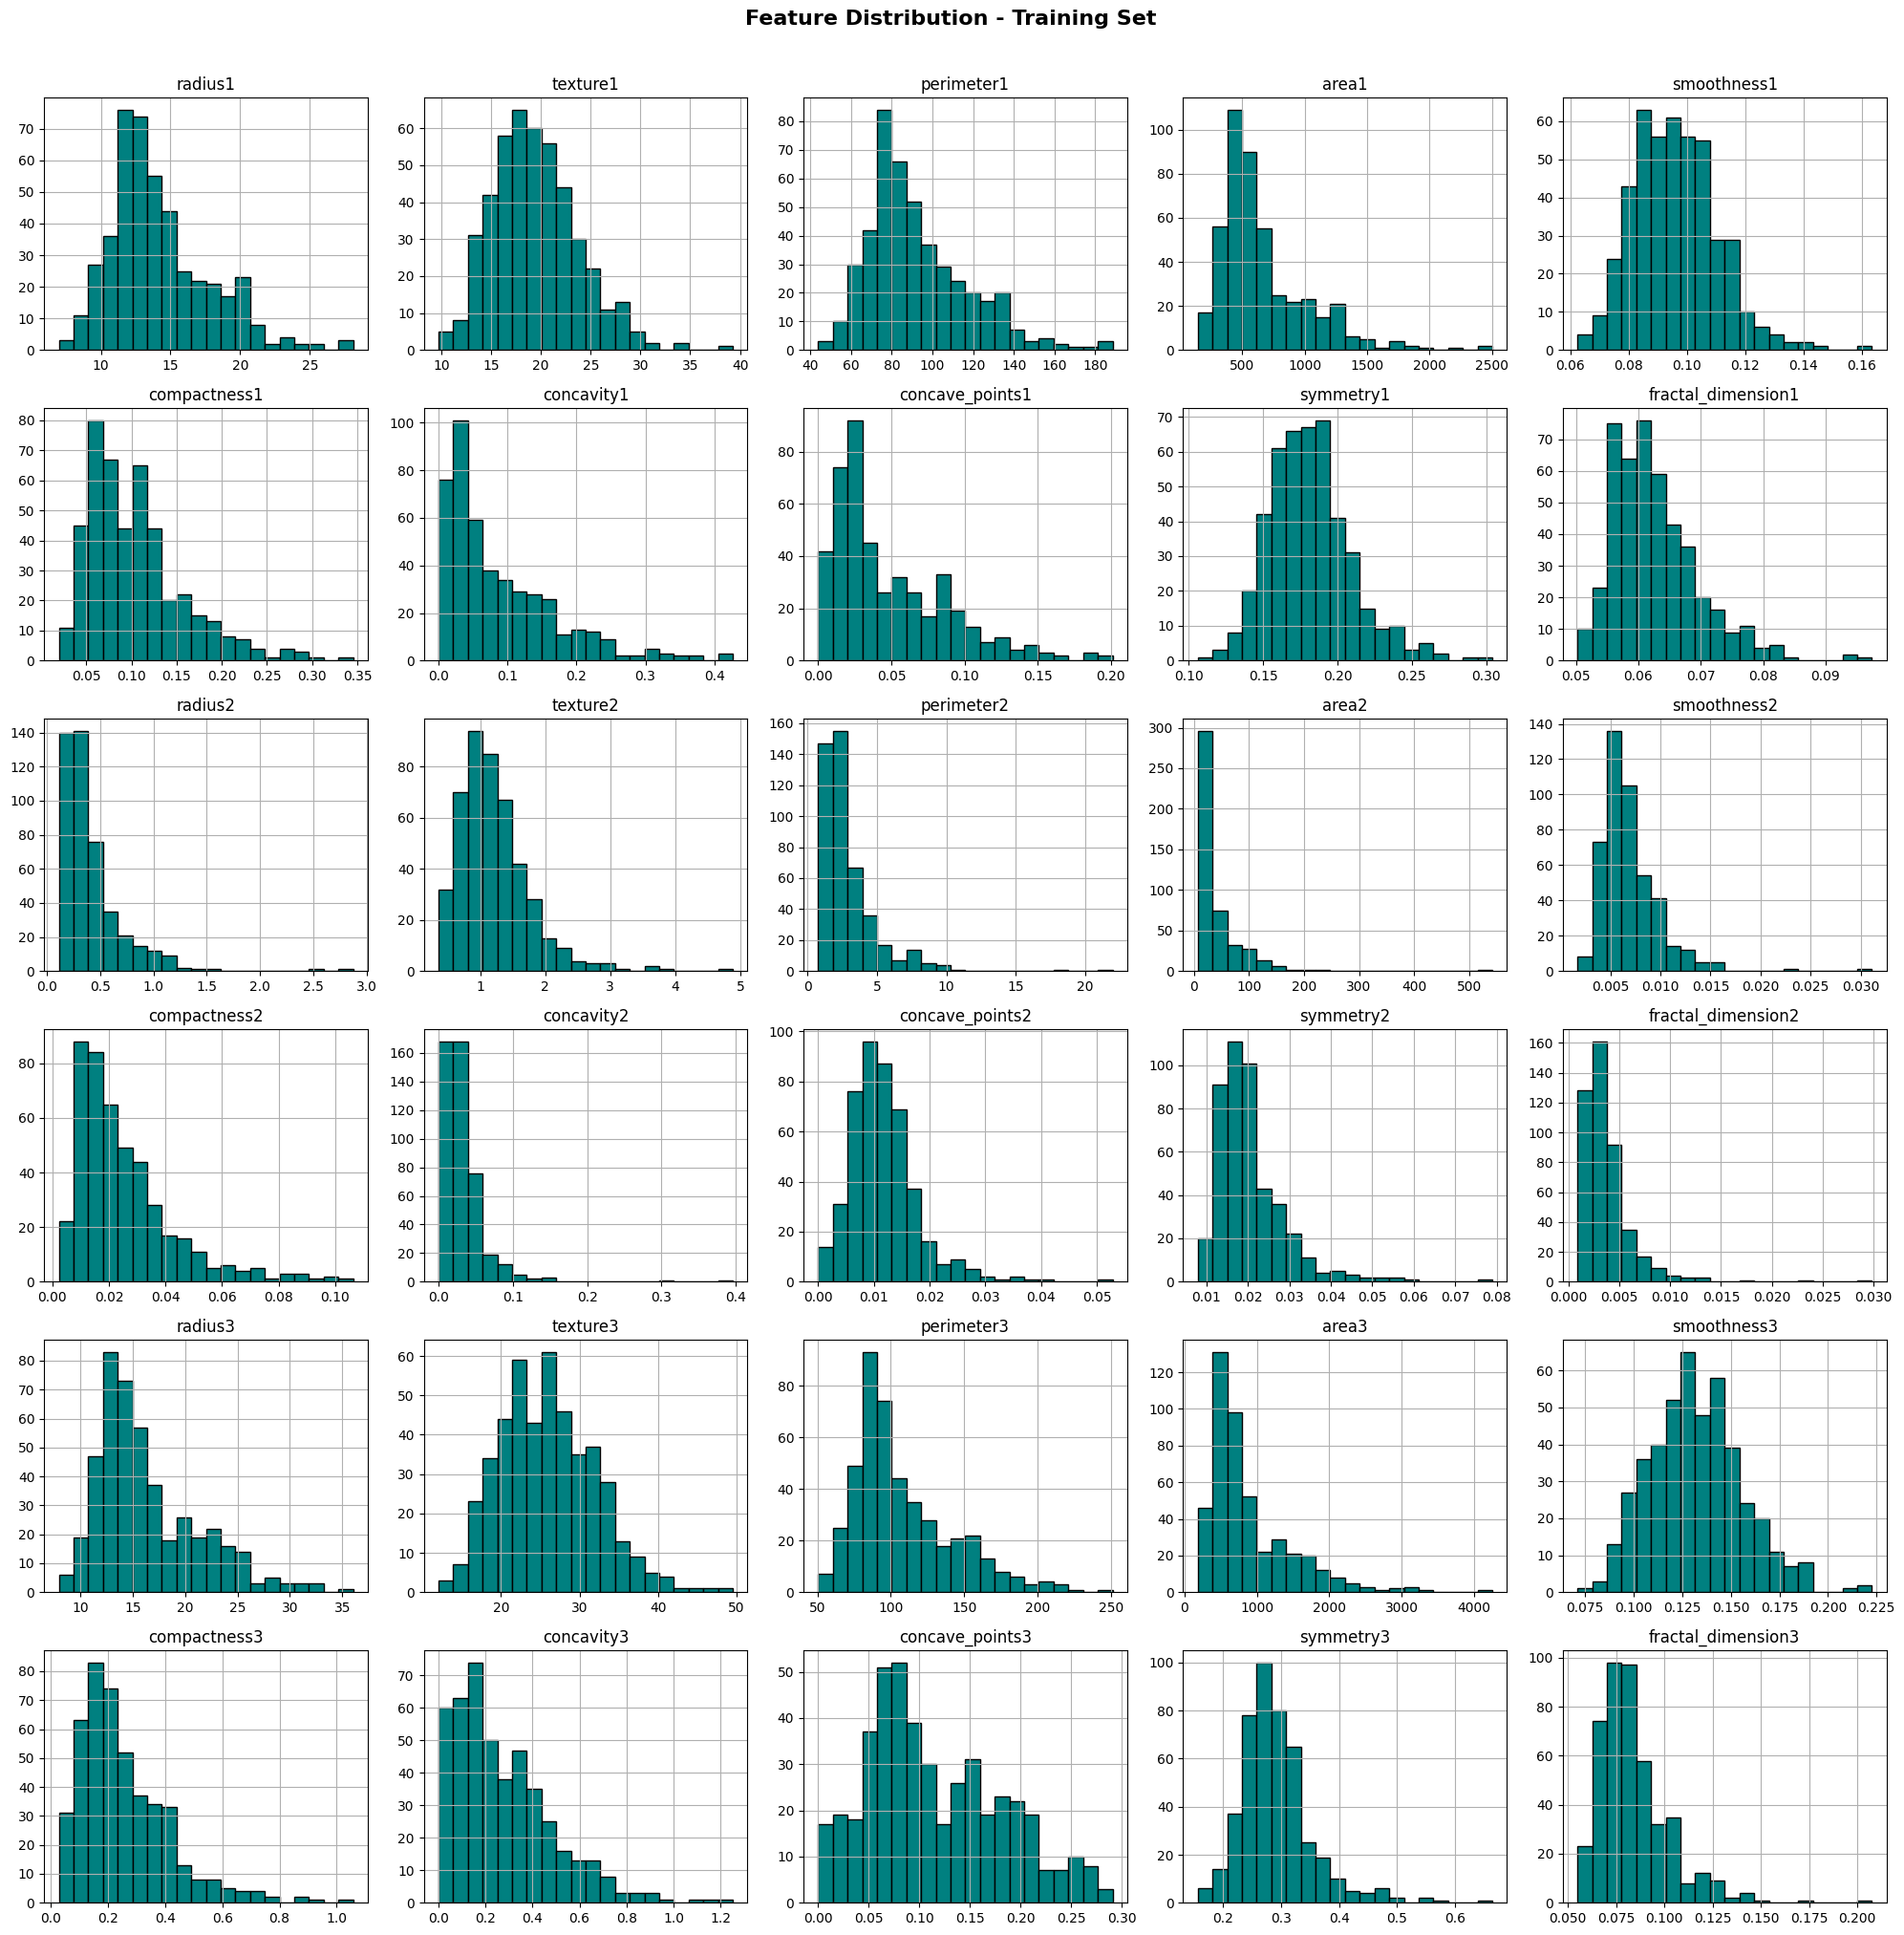

In [11]:
X_train.hist(figsize =(20,20), bins =20,
             color='teal', edgecolor='black')
plt.suptitle('Feature Distribution - Training Set',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('Histogram.png', dpi=150, bbox_inches='tight')
plt.show()

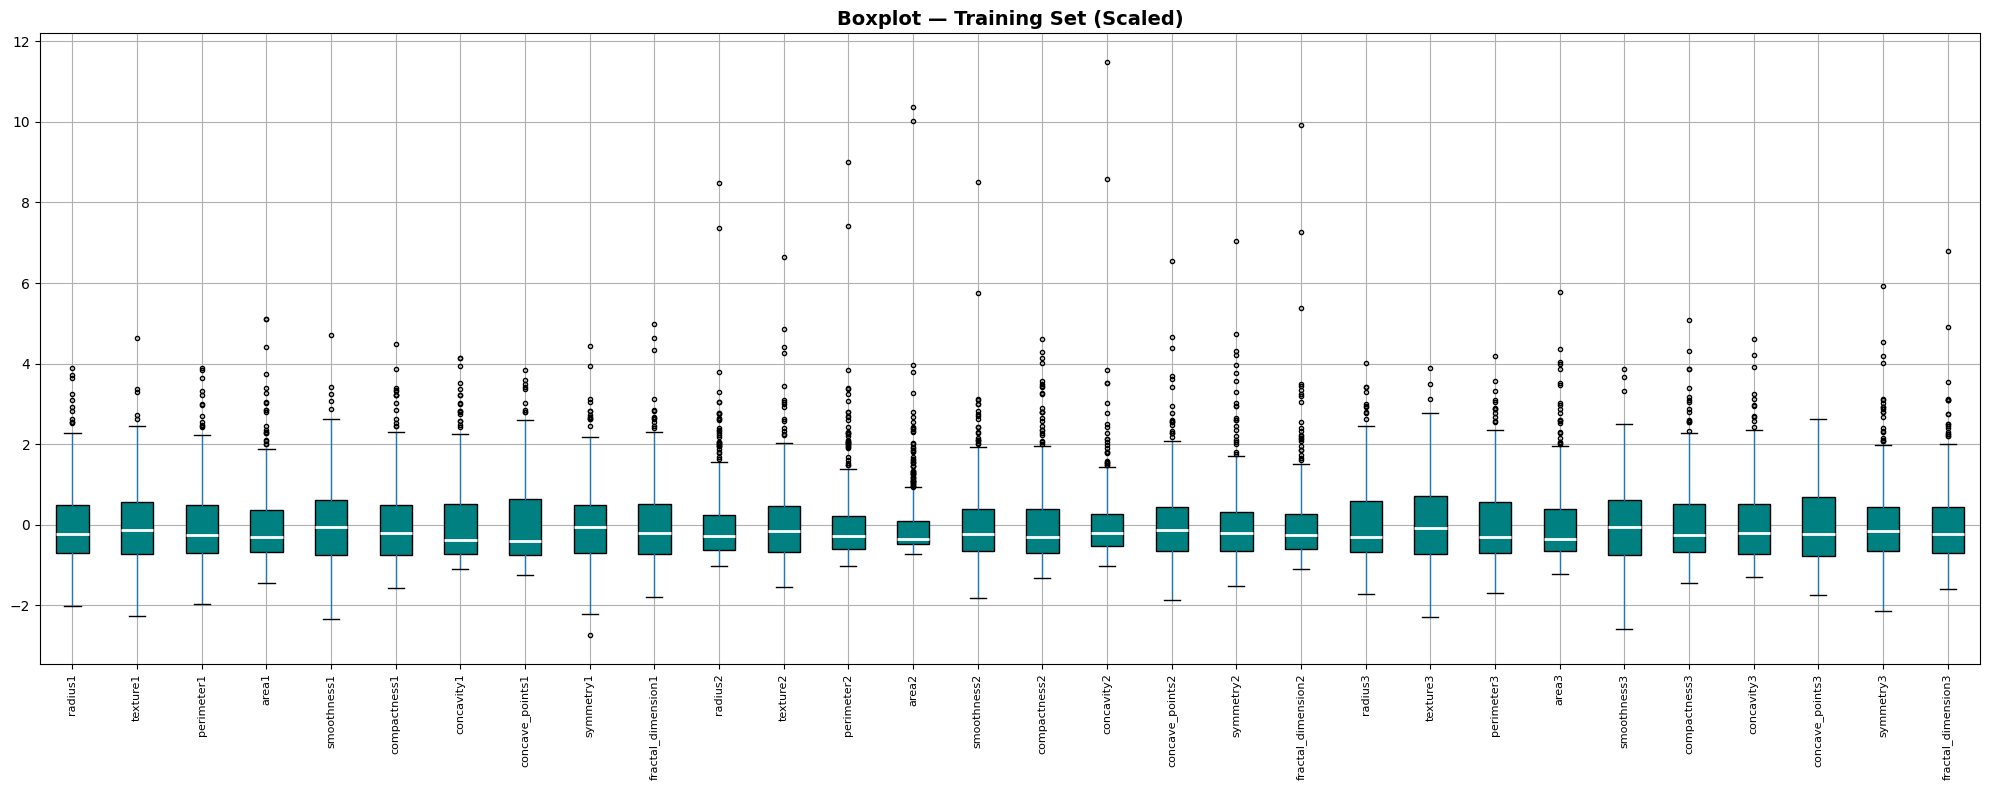

In [12]:
from sklearn.preprocessing import StandardScaler
import pandas as pd
X_train_temp = pd.DataFrame(
    StandardScaler().fit_transform(X_train),
    columns = X_train.columns)

X_train_temp.boxplot(figsize=(20,8), 
                    patch_artist=True,
                    boxprops=dict(facecolor='teal', color='black'),
                    medianprops=dict(color='white', linewidth=2),
                    flierprops=dict(marker ='o', color='red', markersize =3))

plt.xticks(rotation=90, fontsize=8)
plt.title('Boxplot — Training Set (Scaled)', 
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('boxplots.png', dpi=150, bbox_inches='tight')
plt.show()


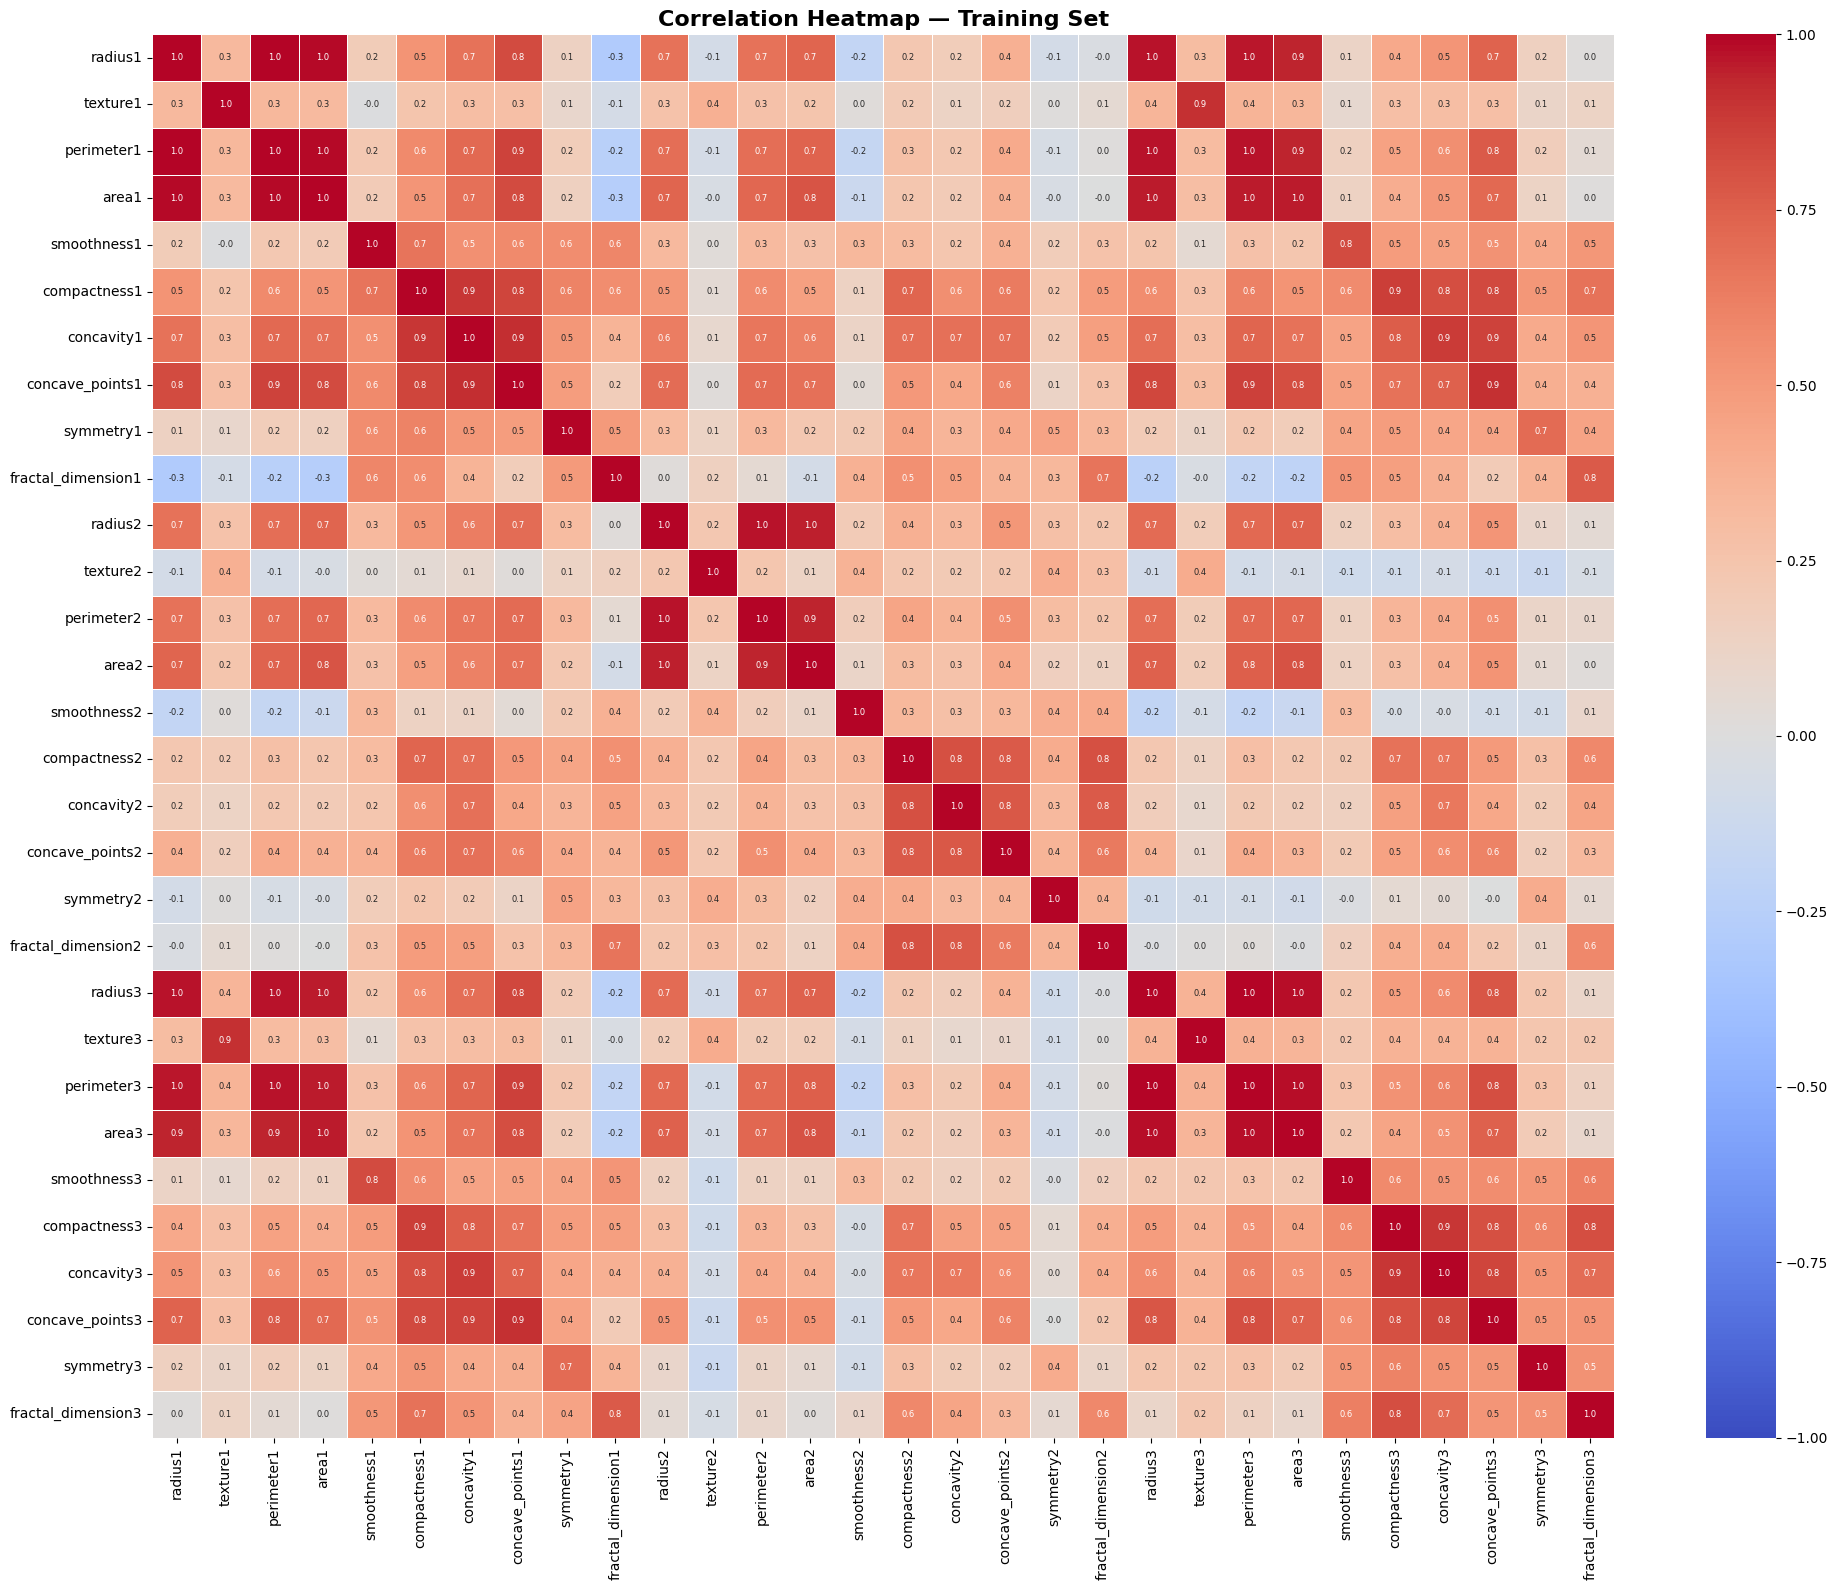

In [13]:

plt.figure(figsize=(20, 16))
sns.heatmap(X_train.corr(),
            annot=True, fmt='.1f',
            annot_kws={'size': 6},
            cmap='coolwarm',
            linewidths=0.5,
            vmin=-1, vmax=1, center=0)

plt.title('Correlation Heatmap — Training Set', 
          fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

 EDA Summary

| Observation | Implication |
|---|---|
| Right skew in size features | Outliers present  StandardScaler needed |
| Heavy outliers in concavity, compactness | Clinically significant not removed |
| radius/perimeter/area correlated at 1.0 | Severe multicollinearity  PCA justified |
| concavity ↔ concave_points  0.9 | Irregularity features redundant |
| All features numeric | No encoding required |

**Key Decision:** 
StandardScaler + PCA required before clustering.
EDA performed on training set only no data leakage.

In [14]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns= X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

print("PREPROCESSING SUMMARY")
print(f"Training set shape:  {X_train_scaled.shape}")
print(f"Testing set shape:   {X_test_scaled.shape}")
print(f"\nTraining mean (should be ~0):")
print(X_train_scaled.mean().round(2))
print(f"\nTraining std (should be ~1):")
print(X_train_scaled.std().round(2))
print(f"\nTest mean (will not be exactly 0):")
print(X_test_scaled.mean().round(2))


PREPROCESSING SUMMARY
Training set shape:  (455, 30)
Testing set shape:   (114, 30)

Training mean (should be ~0):
radius1              -0.0
texture1              0.0
perimeter1            0.0
area1                -0.0
smoothness1           0.0
compactness1         -0.0
concavity1           -0.0
concave_points1       0.0
symmetry1             0.0
fractal_dimension1    0.0
radius2               0.0
texture2             -0.0
perimeter2           -0.0
area2                 0.0
smoothness2          -0.0
compactness2         -0.0
concavity2            0.0
concave_points2      -0.0
symmetry2             0.0
fractal_dimension2   -0.0
radius3              -0.0
texture3              0.0
perimeter3           -0.0
area3                -0.0
smoothness3          -0.0
compactness3         -0.0
concavity3           -0.0
concave_points3       0.0
symmetry3            -0.0
fractal_dimension3    0.0
dtype: float64

Training std (should be ~1):
radius1               1.0
texture1              1.0
perimete

### Preprocessing Summary

| Step | Action | Result |
|---|---|---|
| Fit scaler | StandardScaler fitted on X_train only | Mean=0, Std=1 on training set |
| Transform train | fit_transform(X_train) | 455 × 30 scaled |
| Transform test | transform(X_test) | 114 × 30 scaled  |
| Test mean | Not exactly 0 | Expected uses train statistics |
| Data leakage | None | Test data never seen by scaler  |

**Production rule applied:**
> Scaler fitted on training data only.
> Test data transformed using training statistics.
> This ensures no information from test data influences preprocessing.

 # Principal Component Analysis (PCA)

In [15]:
# Fit PCA on training data only
pca_full = PCA(n_components=30, random_state=42)
pca_full.fit(X_train_scaled)

# Print explained variance
print("Explained Variance per Component:\n")
for i, var in enumerate(pca_full.explained_variance_ratio_):
    cumulative = sum(pca_full.explained_variance_ratio_[:i+1])
    print(f"PC{i+1:02d}: {var*100:.2f}%  |  Cumulative: {cumulative*100:.2f}%")

Explained Variance per Component:

PC01: 44.59%  |  Cumulative: 44.59%
PC02: 18.55%  |  Cumulative: 63.14%
PC03: 9.58%  |  Cumulative: 72.72%
PC04: 6.59%  |  Cumulative: 79.32%
PC05: 5.62%  |  Cumulative: 84.94%
PC06: 3.99%  |  Cumulative: 88.93%
PC07: 2.21%  |  Cumulative: 91.14%
PC08: 1.61%  |  Cumulative: 92.76%
PC09: 1.28%  |  Cumulative: 94.04%
PC10: 1.17%  |  Cumulative: 95.21%
PC11: 1.01%  |  Cumulative: 96.22%
PC12: 0.91%  |  Cumulative: 97.12%
PC13: 0.79%  |  Cumulative: 97.91%
PC14: 0.48%  |  Cumulative: 98.39%
PC15: 0.30%  |  Cumulative: 98.70%
PC16: 0.25%  |  Cumulative: 98.95%
PC17: 0.20%  |  Cumulative: 99.15%
PC18: 0.17%  |  Cumulative: 99.32%
PC19: 0.16%  |  Cumulative: 99.48%
PC20: 0.11%  |  Cumulative: 99.58%
PC21: 0.10%  |  Cumulative: 99.68%
PC22: 0.08%  |  Cumulative: 99.76%
PC23: 0.08%  |  Cumulative: 99.84%
PC24: 0.05%  |  Cumulative: 99.89%
PC25: 0.05%  |  Cumulative: 99.94%
PC26: 0.03%  |  Cumulative: 99.97%
PC27: 0.02%  |  Cumulative: 99.99%
PC28: 0.01%  |  Cu

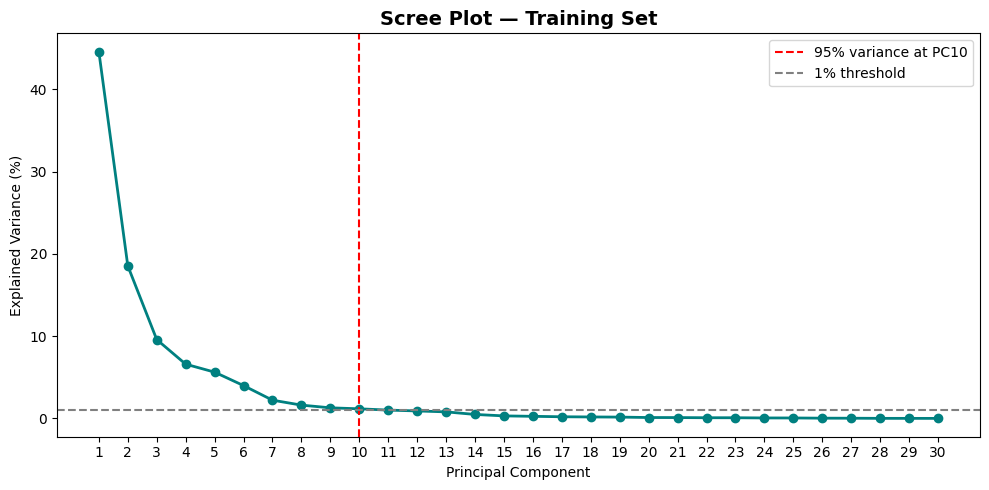

In [16]:


plt.figure(figsize=(10, 5))
plt.plot(range(1, 31),
         pca_full.explained_variance_ratio_ * 100,
         marker='o', color='teal', linewidth=2, markersize=6)

plt.axvline(x=10, color='red', linestyle='--', label='95% variance at PC10')
plt.axhline(y=1, color='gray', linestyle='--', label='1% threshold')
plt.title('Scree Plot — Training Set', fontsize=14, fontweight='bold')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance (%)')
plt.xticks(range(1, 31))
plt.legend()
plt.tight_layout()
plt.savefig('scree_plot.png', dpi=150, bbox_inches='tight')
plt.show()

Apply PCA WITH 10 COMPONENTS

In [ ]:
# Fit on training, transform both sets
pca = PCA(n_components=10, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)


print(f"Training PCA shape:  {X_train_pca.shape}")
print(f"Testing PCA shape:   {X_test_pca.shape}")
print(f"Variance retained:   {sum(pca.explained_variance_ratio_)*100:.2f}%")


Training PCA shape:  (455, 10)
Testing PCA shape:   (114, 10)
Variance retained:   95.21%


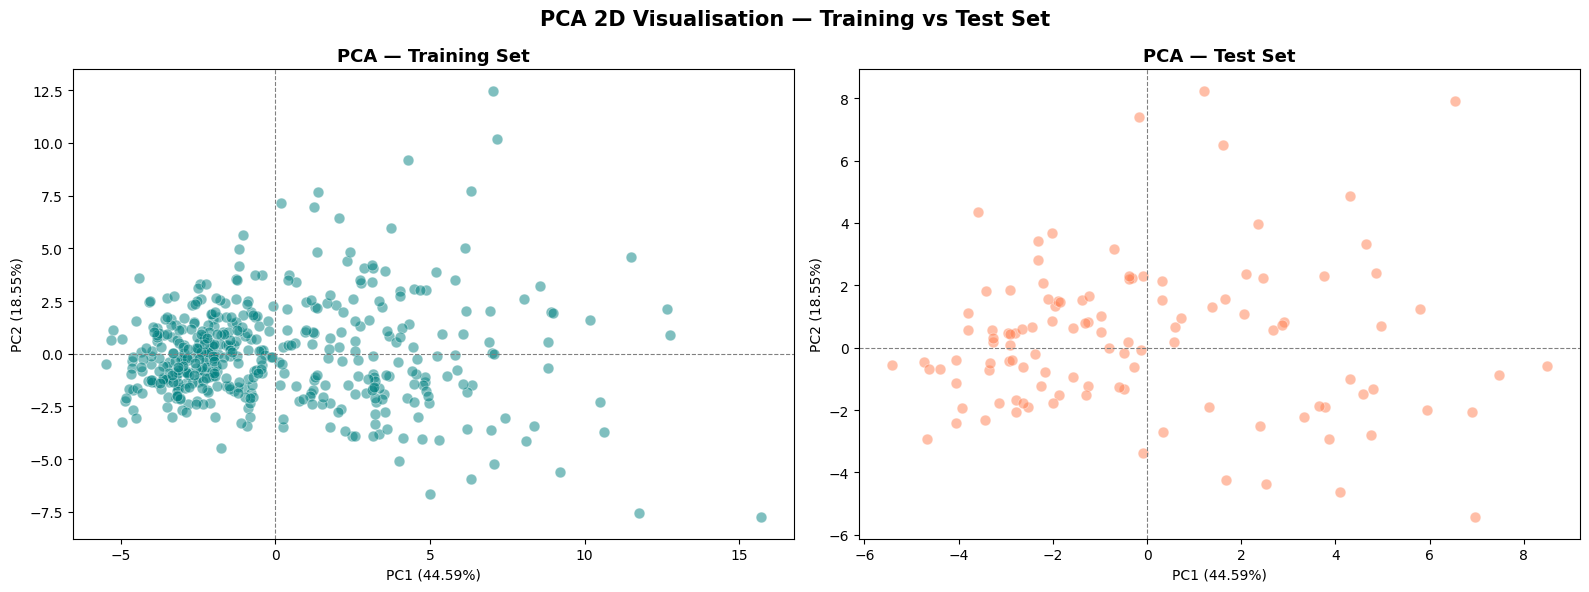

In [25]:
plt.close('all')

# Create 2 component PCA for visualisation
pca_2 = PCA(n_components=2, random_state=42)
X_train_2d = pca_2.fit_transform(X_train_scaled)
X_test_2d = pca_2.transform(X_test_scaled)

# Create dataframes
train_2d = pd.DataFrame(X_train_2d, columns=['PC1', 'PC2'])
test_2d = pd.DataFrame(X_test_2d, columns=['PC1', 'PC2'])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Training set
axes[0].scatter(train_2d['PC1'], train_2d['PC2'],
                c='teal', alpha=0.5,
                edgecolors='white', linewidths=0.5, s=60)
axes[0].set_title('PCA — Training Set', fontsize=13, fontweight='bold')
axes[0].set_xlabel(f'PC1 ({pca_2.explained_variance_ratio_[0]*100:.2f}%)')
axes[0].set_ylabel(f'PC2 ({pca_2.explained_variance_ratio_[1]*100:.2f}%)')
axes[0].axhline(y=0, color='gray', linestyle='--', linewidth=0.8)
axes[0].axvline(x=0, color='gray', linestyle='--', linewidth=0.8)

# Test set
axes[1].scatter(test_2d['PC1'], test_2d['PC2'],
                c='coral', alpha=0.5,
                edgecolors='white', linewidths=0.5, s=60)
axes[1].set_title('PCA — Test Set', fontsize=13, fontweight='bold')
axes[1].set_xlabel(f'PC1 ({pca_2.explained_variance_ratio_[0]*100:.2f}%)')
axes[1].set_ylabel(f'PC2 ({pca_2.explained_variance_ratio_[1]*100:.2f}%)')
axes[1].axhline(y=0, color='gray', linestyle='--', linewidth=0.8)
axes[1].axvline(x=0, color='gray', linestyle='--', linewidth=0.8)

plt.suptitle('PCA 2D Visualisation — Training vs Test Set',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('pca_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

PCA Visualisation Summary

Training Set (PC1: 44.59%, PC2: 18.55%)

- Dense cluster on the left  uniform patient group
- Spread group on the right variable patient group
- Natural separation visible around PC1 = 0

Test Set
- Confirms same two-group structure as training set
- PCA components generalise well to unseen data
- Both sets show consistent patient population structure

-  Two natural patient groups are visible in both trainin and test sets validating that the structure is real and not specific to the training data.

# Implementation of KMeans CLustering

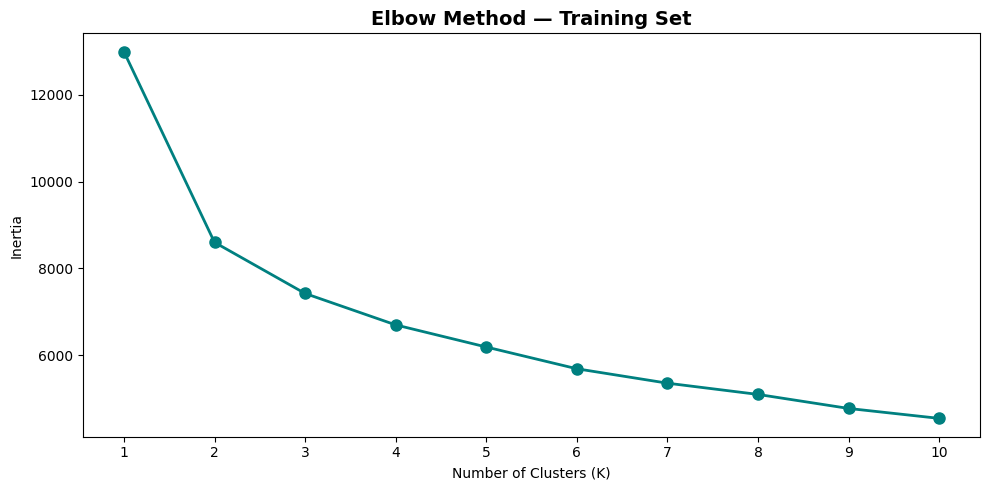

In [19]:
plt.close('all')

inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_train_pca)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(K_range, inertia, marker='o', color='teal',
         linewidth=2, markersize=8)
plt.title('Elbow Method — Training Set', fontsize=14, fontweight='bold')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.xticks(K_range)
plt.tight_layout()
plt.savefig('elbow_plot.png', dpi=150, bbox_inches='tight')
plt.show()

In [20]:
# Fit K-Means on training data only
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
kmeans.fit(X_train_pca)

# Assign cluster labels to both sets
train_clusters = kmeans.predict(X_train_pca)
test_clusters = kmeans.predict(X_test_pca)


print("K-MEANS CLUSTERING SUMMARY")
print(f"\nTraining cluster distribution:")
print(pd.Series(train_clusters).value_counts())
print(f"\nTest cluster distribution:")
print(pd.Series(test_clusters).value_counts())


K-MEANS CLUSTERING SUMMARY

Training cluster distribution:
1    297
0    158
Name: count, dtype: int64

Test cluster distribution:
1    78
0    36
Name: count, dtype: int64


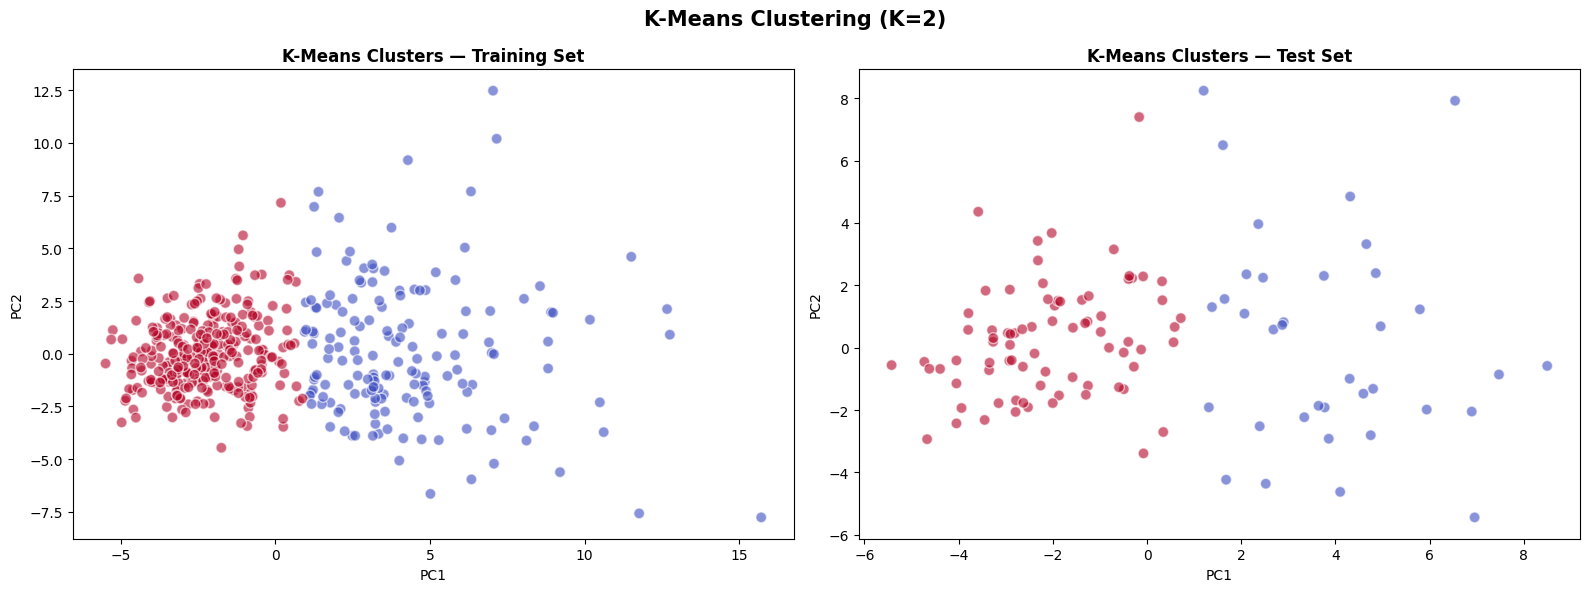

In [21]:
plt.close('all')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, data_2d, labels, title in zip(
    axes,
    [X_train_2d, X_test_2d],
    [train_clusters, test_clusters],
    ['Training Set', 'Test Set']):

    ax.scatter(data_2d[:, 0], data_2d[:, 1],
               c=labels, cmap='coolwarm',
               alpha=0.6, edgecolors='white', s=60)
    ax.set_title(f'K-Means Clusters — {title}', fontweight='bold')
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')

plt.suptitle('K-Means Clustering (K=2)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('kmeans_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

 K-Means Clustering Summary

| Set | Cluster 0 | Cluster 1 | Total |
|---|---|---|---|
| Training | 158 | 297 | 455 |
| Testing | 36 | 78 | 114 |

Visual Findings:
- Both training and test sets show clean cluster separation
- Red cluster (1) dense, uniform group likely benign profile
- Blue cluster (0) spread, variable group  likely malignant profile
- Consistent structure across both sets confirms K-Means generalised well

Production Rule Applied:
- K-Means fitted on training data only
- Test clusters assigned using trained model
- No data leakage

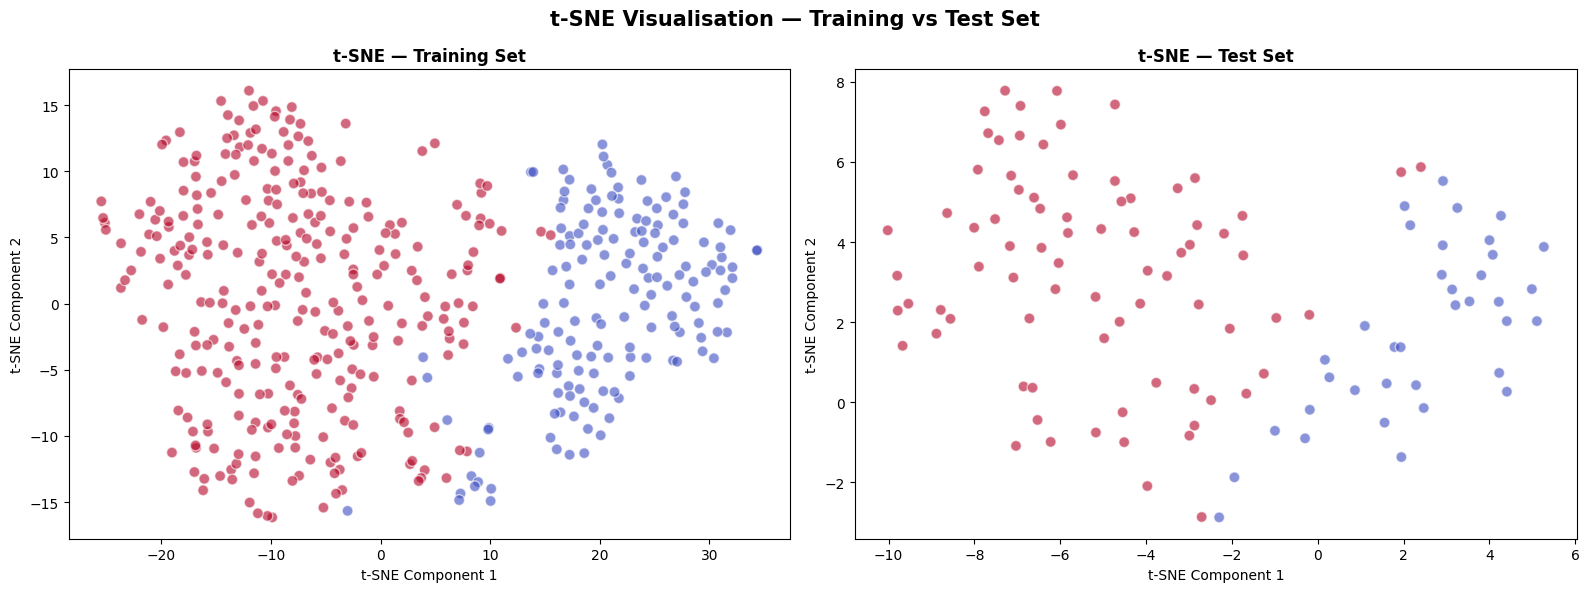

In [22]:
from sklearn.manifold import TSNE

plt.close('all')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, data, labels, title in zip(
    axes,
    [X_train_scaled, X_test_scaled],
    [train_clusters, test_clusters],
    ['Training Set', 'Test Set']):

    tsne = TSNE(n_components=2, random_state=42, perplexity=30)
    data_tsne = tsne.fit_transform(data)

    ax.scatter(data_tsne[:, 0], data_tsne[:, 1],
               c=labels, cmap='coolwarm',
               alpha=0.6, edgecolors='white', s=60)
    ax.set_title(f't-SNE — {title}', fontweight='bold')
    ax.set_xlabel('t-SNE Component 1')
    ax.set_ylabel('t-SNE Component 2')

plt.suptitle('t-SNE Visualisation — Training vs Test Set',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('tsne_plot.png', dpi=150, bbox_inches='tight')
plt.show()

t-SNE Visualisation Summary

Both training and test sets show clean cluster separation:
- Red (Cluster 1)  large uniform group on the left
- Blue (Cluster 0)  distinct group on the right
- Cleaner separation than PCA confirms two genuine patient populations
- Consistent structure across training and test sets

Note: t-SNE is used for visualisation only.


In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Define models
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss')
}

# Train and evaluate
results = {}

for name, model in models.items():
    # Train on scaled training features
    model.fit(X_train_scaled, train_clusters)   

    # Predict on test set
    preds = model.predict(X_test_scaled)
    auc = roc_auc_score(y_true=test_clusters,
                        y_score=model.predict_proba(X_test_scaled)[:, 1])

    # Store results
    results[name] = {'predictions': preds, 'auc': auc}


    print(f"  {name}")
    print(classification_report(test_clusters, preds))
    print(f"ROC-AUC: {auc:.4f}")

  Logistic Regression
              precision    recall  f1-score   support

           0       0.97      1.00      0.99        36
           1       1.00      0.99      0.99        78

    accuracy                           0.99       114
   macro avg       0.99      0.99      0.99       114
weighted avg       0.99      0.99      0.99       114

ROC-AUC: 1.0000
  Random Forest
              precision    recall  f1-score   support

           0       0.97      1.00      0.99        36
           1       1.00      0.99      0.99        78

    accuracy                           0.99       114
   macro avg       0.99      0.99      0.99       114
weighted avg       0.99      0.99      0.99       114

ROC-AUC: 1.0000
  XGBoost
              precision    recall  f1-score   support

           0       0.92      1.00      0.96        36
           1       1.00      0.96      0.98        78

    accuracy                           0.97       114
   macro avg       0.96      0.98      0.97     

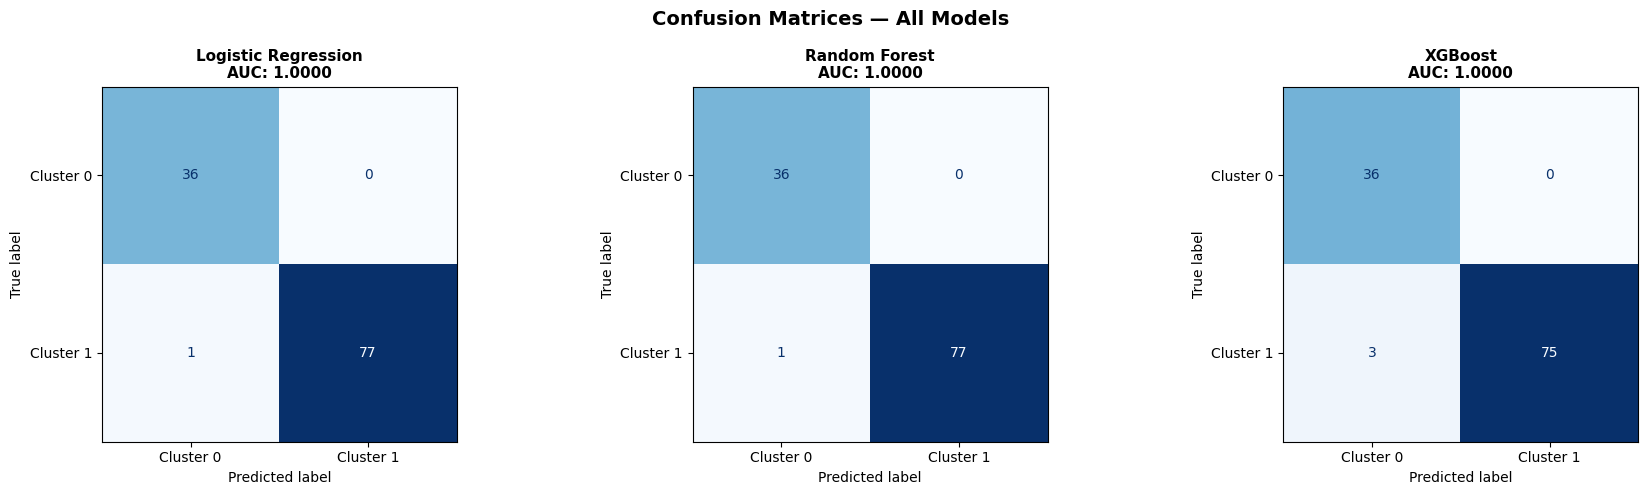

In [27]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, result) in zip(axes, results.items()):
    cm = confusion_matrix(test_clusters, result['predictions'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=['Cluster 0', 'Cluster 1'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name}\nAUC: {result["auc"]:.4f}',
                 fontweight='bold', fontsize=11)

plt.suptitle('Confusion Matrices — All Models',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

In [29]:
from sklearn.model_selection import cross_val_score

print("5-FOLD CROSS VALIDATION RESULTS")

for name, model in models.items():
    scores = cross_val_score(model, X_train_scaled,
                             train_clusters, cv=5,
                             scoring='accuracy')
    print(f"\n{name}")
    print(f"Fold Scores: {scores.round(4)}")
    print(f"Mean:  {scores.mean():.4f}")
    print(f"Std:   {scores.std():.4f}")
    print(f"Min:   {scores.min():.4f}")
    print(f"Max:   {scores.max():.4f}")



5-FOLD CROSS VALIDATION RESULTS

Logistic Regression
Fold Scores: [1.    0.978 1.    0.989 1.   ]
Mean:  0.9934
Std:   0.0088
Min:   0.9780
Max:   1.0000

Random Forest
Fold Scores: [0.967  1.     0.989  0.9451 0.989 ]
Mean:  0.9780
Std:   0.0197
Min:   0.9451
Max:   1.0000

XGBoost
Fold Scores: [0.967  1.     0.9451 0.956  1.    ]
Mean:  0.9736
Std:   0.0226
Min:   0.9451
Max:   1.0000


 Cross Validation Summary

| Model | CV Mean | Std | Overfitting |
|---|---|---|---|
| Logistic Regression | 99.34% | 0.0088 | None |
| Random Forest | 97.80% | 0.0197 | Minimal |
| XGBoost | 97.36% | 0.0226 | Minimal |


- All gaps between test accuracy and CV mean are below 1.5%
- No significant overfitting detected
- Cluster boundaries are largely linear  confirmed by LR dominance

 # Hyperpamater Tunning

In [30]:
from sklearn.model_selection import GridSearchCV

# Define parameter grids
param_grids = {
    'Logistic Regression': {
        'C': [0.01, 0.1, 1, 10, 100],
        'solver': ['lbfgs', 'liblinear'],
        'max_iter': [1000]
    },
    'Random Forest': {
        'n_estimators': [50, 100, 200],
        'max_depth': [None, 5, 10],
        'min_samples_split': [2, 5]
    },
    'XGBoost': {
        'n_estimators': [50, 100, 200],
        'max_depth': [3, 5, 7],
        'learning_rate': [0.01, 0.1, 0.3]
    }
}

best_models = {}

for name, model in models.items():
    print(f"\nTuning {name}...")
    grid = GridSearchCV(model,
                        param_grids[name],
                        cv=5,
                        scoring='accuracy',
                        n_jobs=-1)
    grid.fit(X_train_scaled, train_clusters)
    best_models[name] = grid.best_estimator_
    print(f"Best params: {grid.best_params_}")
    print(f"Best CV score: {grid.best_score_:.4f}")


Tuning Logistic Regression...
Best params: {'C': 1, 'max_iter': 1000, 'solver': 'lbfgs'}
Best CV score: 0.9934

Tuning Random Forest...
Best params: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 50}
Best CV score: 0.9802

Tuning XGBoost...
Best params: {'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 200}
Best CV score: 0.9736


 Hyperparameter Tuning Summary

| Model | Best Params | CV Score |
|---|---|---|
| Logistic Regression | C=1, solver=lbfgs | 99.34% |
| Random Forest | max_depth=None, n_estimators=50 | 98.02% |
| XGBoost | learning_rate=0.01, max_depth=5 | 97.36% |

- Tuning produced minimal improvement default parameters were already near optimal for this dataset.
- Logistic Regression confirmed as best model.

 # COMPARISON: CLUSTER LABELS vs ORIGINAL DIAGNOSIS LABELS

In [32]:
from sklearn.metrics import accuracy_score

# Convert M/B to 1/0
y_train_binary = (y_train['Diagnosis'] == 'M').astype(int)
y_test_binary = (y_test['Diagnosis'] == 'M').astype(int)


print("CLUSTER LABELS vs ORIGINAL DIAGNOSIS LABELS")


# Train fresh models on original labels
lr_orig = LogisticRegression(random_state=42, max_iter=1000)
rf_orig = RandomForestClassifier(n_estimators=50, random_state=42)
xgb_orig = XGBClassifier(random_state=42, eval_metric='logloss')

orig_models = {
    'Logistic Regression': lr_orig,
    'Random Forest': rf_orig,
    'XGBoost': xgb_orig
}

for name, model in orig_models.items():
    # Train on original diagnosis
    model.fit(X_train_scaled, y_train_binary)
    preds = model.predict(X_test_scaled)
    acc = accuracy_score(y_test_binary, preds)
    auc = roc_auc_score(y_test_binary,
                        model.predict_proba(X_test_scaled)[:, 1])
    print(f"\n{name}")
    print(f"Accuracy: {acc:.4f}")
    print(f"ROC-AUC:  {auc:.4f}")



CLUSTER LABELS vs ORIGINAL DIAGNOSIS LABELS

Logistic Regression
Accuracy: 0.9649
ROC-AUC:  0.9960

Random Forest
Accuracy: 0.9737
ROC-AUC:  0.9940

XGBoost
Accuracy: 0.9737
ROC-AUC:  0.9940


Cluster Labels vs Original Diagnosis Comparison

| Model | Cluster Accuracy | Original Accuracy | Cluster AUC | Original AUC |
|---|---|---|---|---|
| Logistic Regression | 99.1% | 96.49% | 1.0000 | 0.9960 |
| Random Forest | 99.1% | 97.37% | 1.0000 | 0.9940 |
| XGBoost | 97.4% | 97.37% | 1.0000 | 0.9940 |

**Key Finding:**
- Cluster label scores are higher due to clean mathematical boundaries
- Original diagnosis scores reflect true clinical predictive power
- All models achieve 96-97% on real diagnosis  genuinely strong
- XGBoost most consistent smallest gap between both evaluations
- Confirms K-Means clusters are clinically meaningful not just mathematical

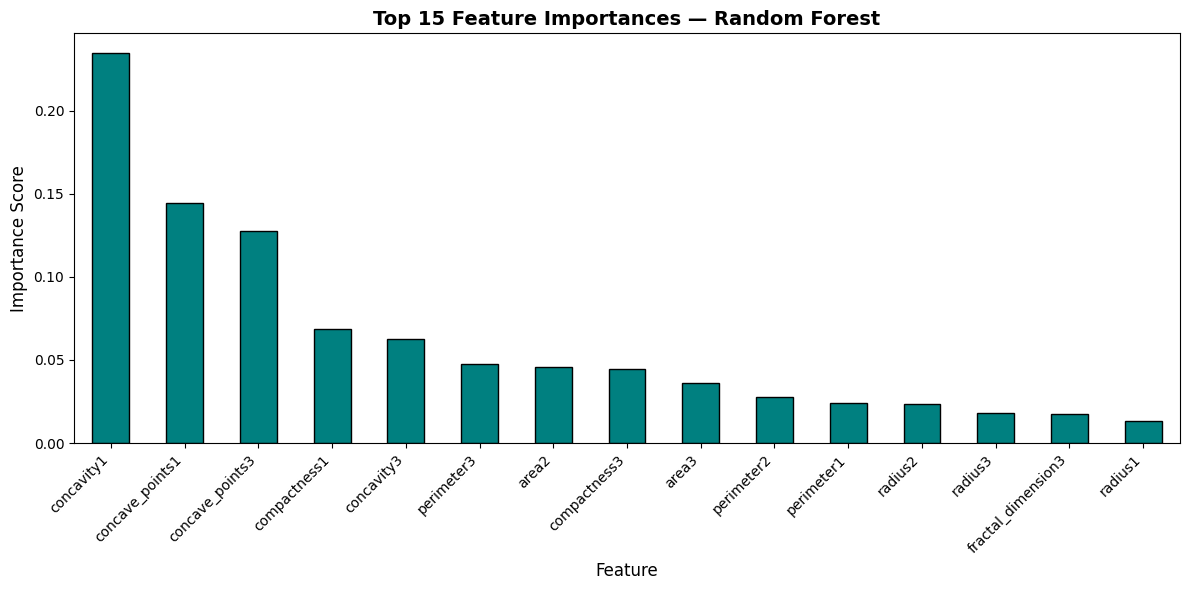

Top 10 Features:
concavity1         0.2349
concave_points1    0.1444
concave_points3    0.1275
compactness1       0.0689
concavity3         0.0624
perimeter3         0.0478
area2              0.0455
compactness3       0.0447
area3              0.0361
perimeter2         0.0275
dtype: float64


In [33]:
plt.close('all')

# Get feature importance from best Random Forest
rf_best = best_models['Random Forest']

feature_importance = pd.Series(
    rf_best.feature_importances_,
    index=X_train_scaled.columns
).sort_values(ascending=False)

plt.figure(figsize=(12, 6))
feature_importance.head(15).plot(kind='bar', color='teal', edgecolor='black')
plt.title('Top 15 Feature Importances — Random Forest',
          fontsize=14, fontweight='bold')
plt.xlabel('Feature', fontsize=12)
plt.ylabel('Importance Score', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("Top 10 Features:")
print(feature_importance.head(10).round(4))

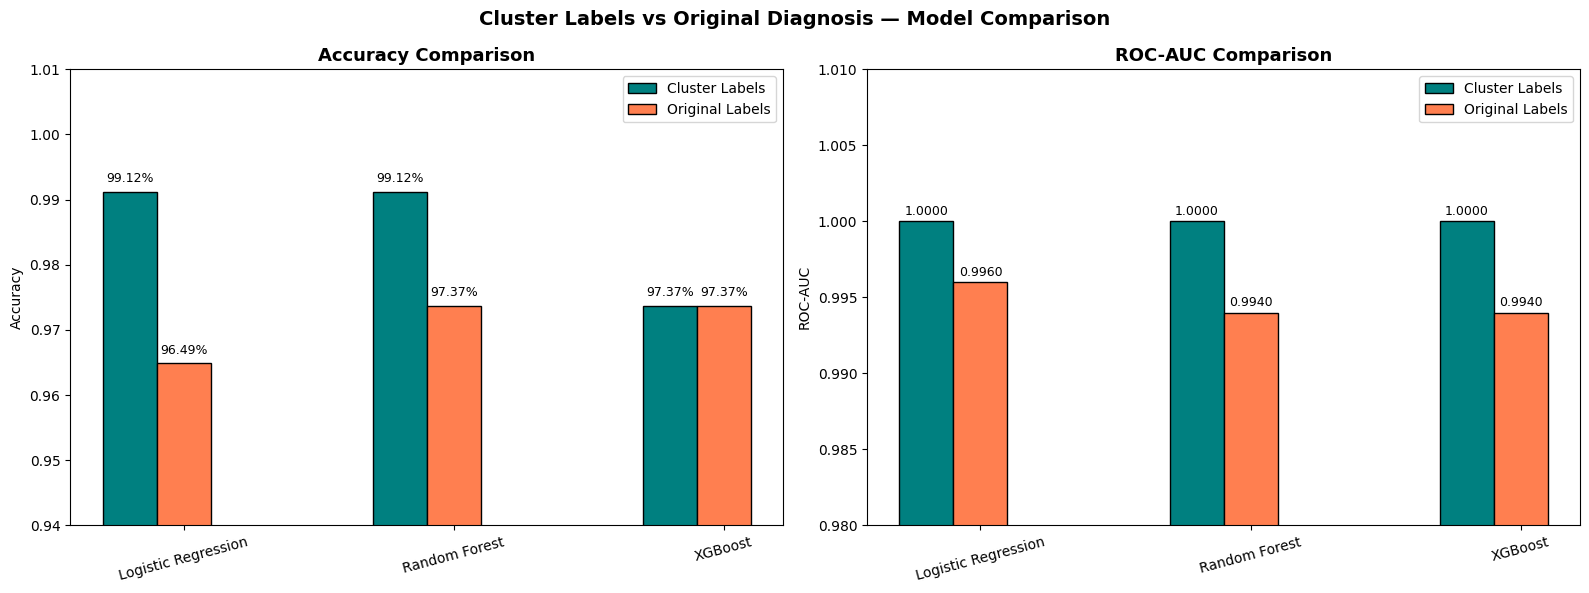

In [34]:
plt.close('all')

model_names = ['Logistic Regression', 'Random Forest', 'XGBoost']
cluster_acc = [0.9912, 0.9912, 0.9737]
original_acc = [0.9649, 0.9737, 0.9737]
cluster_auc = [1.0000, 1.0000, 1.0000]
original_auc = [0.9960, 0.9940, 0.9940]

x = range(len(model_names))
width = 0.2

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Accuracy comparison
axes[0].bar([i - width for i in x], cluster_acc, width,
            label='Cluster Labels', color='teal', edgecolor='black')
axes[0].bar([i for i in x], original_acc, width,
            label='Original Labels', color='coral', edgecolor='black')
axes[0].set_title('Accuracy Comparison', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Accuracy')
axes[0].set_xticks(x)
axes[0].set_xticklabels(model_names, rotation=15)
axes[0].set_ylim(0.94, 1.01)
axes[0].legend()

# Add value labels
for i, (c, o) in enumerate(zip(cluster_acc, original_acc)):
    axes[0].text(i - width, c + 0.001, f'{c:.2%}',
                ha='center', va='bottom', fontsize=9)
    axes[0].text(i, o + 0.001, f'{o:.2%}',
                ha='center', va='bottom', fontsize=9)

# AUC comparison
axes[1].bar([i - width for i in x], cluster_auc, width,
            label='Cluster Labels', color='teal', edgecolor='black')
axes[1].bar([i for i in x], original_auc, width,
            label='Original Labels', color='coral', edgecolor='black')
axes[1].set_title('ROC-AUC Comparison', fontsize=13, fontweight='bold')
axes[1].set_ylabel('ROC-AUC')
axes[1].set_xticks(x)
axes[1].set_xticklabels(model_names, rotation=15)
axes[1].set_ylim(0.98, 1.01)
axes[1].legend()

# Add value labels
for i, (c, o) in enumerate(zip(cluster_auc, original_auc)):
    axes[1].text(i - width, c + 0.0002, f'{c:.4f}',
                ha='center', va='bottom', fontsize=9)
    axes[1].text(i, o + 0.0002, f'{o:.4f}',
                ha='center', va='bottom', fontsize=9)

plt.suptitle('Cluster Labels vs Original Diagnosis — Model Comparison',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### Model Comparison:  Cluster vs Original Labels



- Cluster scores higher due to clean K-Means boundaries
- Original scores reflect true clinical predictive power
- XGBoost most consistent across both evaluations
- All models clinically strong  AUC above 0.994

In [41]:
# Get probabilities from best model
rf_best = best_models['Random Forest']
probs = rf_best.predict_proba(X_test_scaled)[:, 1]

# Test different thresholds
thresholds = [0.5, 0.4, 0.3, 0.2]

print("=" * 65)
print(f"{'Threshold':<12} {'Accuracy':<12} {'Recall':<12} {'Precision':<12} {'F1':<10}")
print("=" * 65)

from sklearn.metrics import recall_score, precision_score, f1_score

for threshold in thresholds:
    preds_t = (probs >= threshold).astype(int)
    acc = accuracy_score(test_clusters, preds_t)
    rec = recall_score(test_clusters, preds_t)
    pre = precision_score(test_clusters, preds_t)
    f1 = f1_score(test_clusters, preds_t)
    print(f"{threshold:<12} {acc:<12.4f} {rec:<12.4f} {pre:<12.4f} {f1:<10.4f}")

print("=" * 65)

Threshold    Accuracy     Recall       Precision    F1        
0.5          0.9825       0.9744       1.0000       0.9870    
0.4          0.9912       0.9872       1.0000       0.9935    
0.3          0.9912       1.0000       0.9873       0.9936    
0.2          0.9649       1.0000       0.9512       0.9750    


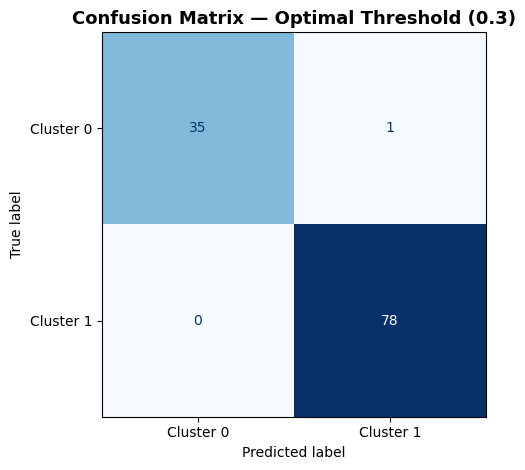

In [42]:
plt.close('all')

# Apply threshold 0.3
preds_optimal = (probs >= 0.3).astype(int)

cm = confusion_matrix(test_clusters, preds_optimal)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=['Cluster 0', 'Cluster 1'])
disp.plot(colorbar=False, cmap='Blues')
plt.title('Confusion Matrix — Optimal Threshold (0.3)',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix_optimal.png', dpi=150, bbox_inches='tight')
plt.show()

### Optimal Threshold Analysis

Default threshold of 0.5 missed 2 malignant patients, a dangerous outcome in clinical settings.

Threshold adjusted to 0.3 after systematic evaluation:

| Threshold | Recall | Precision | Accuracy |
|---|---|---|---|
| 0.5 (default) | 97.44% | 100% | 98.25% |
| **0.3 (optimal)** | **100%** | **98.73%** | **99.12%** |

**At threshold 0.3:**
- Zero malignant patients missed (False Negatives = 0)
- Only 1 benign patient incorrectly flagged
- All 78 Cluster 1 patients correctly identified

**Clinical justification:**
> In cancer screening, missing a malignant patient is far more
> dangerous than a false alarm. One unnecessary follow-up
> appointment is always preferable to one missed cancer diagnosis.
> Threshold of 0.3 is recommended for production deployment.

##  Model Explainability: SHapley Additive exPlanations (SHAP)

SHAP explains why the model made each prediction.
Shows which features pushed each patient toward
Cluster 0 or Cluster 1.

In [35]:
!pip install shap
import shap

print("SHAP imported successfully.")

   ---------------------------------------- 0.0/38.1 MB ? eta -:--:--
    --------------------------------------- 0.5/38.1 MB 2.4 MB/s eta 0:00:16
   - -------------------------------------- 1.6/38.1 MB 3.7 MB/s eta 0:00:11
   -- ------------------------------------- 2.6/38.1 MB 4.2 MB/s eta 0:00:09
   --- ------------------------------------ 3.7/38.1 MB 4.7 MB/s eta 0:00:08
   --- ------------------------------------ 3.7/38.1 MB 4.7 MB/s eta 0:00:08
   --- ------------------------------------ 3.7/38.1 MB 4.7 MB/s eta 0:00:08
   --- ------------------------------------ 3.7/38.1 MB 4.7 MB/s eta 0:00:08
   --- ------------------------------------ 3.7/38.1 MB 4.7 MB/s eta 0:00:08
   --- ------------------------------------ 3.7/38.1 MB 4.7 MB/s eta 0:00:08
   ---- ----------------------------------- 4.7/38.1 MB 2.2 MB/s eta 0:00:16
   ------ --------------------------------- 6.6/38.1 MB 2.9 MB/s eta 0:00:11
   ------- -------------------------------- 7.6/38.1 MB 2.9 MB/s eta 0:00:11
   ---

c:\Users\Hp\anaconda3\envs\SQL_Environment\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


SHAP imported successfully.


In [36]:
# Use Random Forest — best for SHAP tree explainer
rf_best = best_models['Random Forest']

# Create SHAP explainer
explainer = shap.TreeExplainer(rf_best)
shap_values = explainer.shap_values(X_test_scaled)

print("SHAP values calculated successfully.")
print(f"SHAP values shape: {shap_values[0].shape}")

SHAP values calculated successfully.
SHAP values shape: (30, 2)


In [39]:
plt.close('all')

# Check shap_values structure
print(type(shap_values))
print(len(shap_values))
print(shap_values[0].shape)

<class 'numpy.ndarray'>
114
(30, 2)


Reshaped SHAP values: (114, 30)


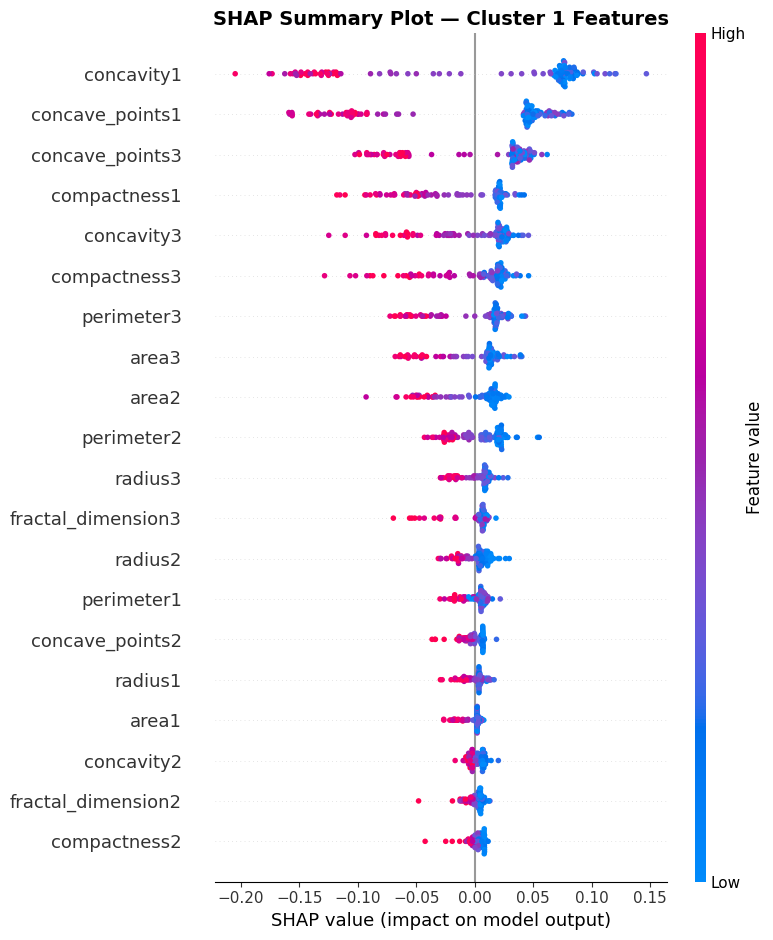

In [40]:
plt.close('all')

# Reshape shap values correctly
shap_vals = np.array([shap_values[i][:, 1] for i in range(len(shap_values))])

print("Reshaped SHAP values:", shap_vals.shape)

shap.summary_plot(shap_vals,
                  X_test_scaled,
                  feature_names=list(X_test_scaled.columns),
                  show=False)

plt.title('SHAP Summary Plot — Cluster 1 Features',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

### SHAP Explainability Summary

**Method:** TreeExplainer applied to tuned Random Forest
**Target:** Cluster 1 (malignant profile) SHAP values


**Key Findings:**

| Feature | SHAP Pattern | Clinical Meaning |
|---|---|---|
| concavity1 | High = pushes right | High nuclear concavity = malignant signal |
| concave_points1 | High = pushes right | More concave points = malignant signal |
| concave_points3 | High = pushes right | Worst case concave points = malignant |
| compactness1 | High = pushes right | Dense irregular nuclei = malignant |
| area3 | High = pushes right | Large worst case area = malignant |

**Overall Finding:**
- High values of irregularity features (concavity, concave points, compactness) consistently push patients toward the malignant cluster.

- Low values push toward the benign cluster.The model's decisions are clinically interpretable and align with known pathological markers of malignancy.

In [44]:
import joblib
import os

In [45]:
# ================================================
# VERSION 1 — Trained on Cluster Labels
# For: Patient Profiling
# ================================================



os.makedirs('models', exist_ok=True)

# Best model from CV — Logistic Regression
lr_cluster = LogisticRegression(random_state=42, max_iter=1000)
lr_cluster.fit(X_train_scaled, train_clusters)

# ================================================
# VERSION 2 — Trained on Original Diagnosis Labels
# For: Clinical Decision Support
# ================================================

# Convert M/B to 1/0
y_train_binary = (y_train['Diagnosis'] == 'M').astype(int)
y_test_binary = (y_test['Diagnosis'] == 'M').astype(int)

lr_clinical = LogisticRegression(random_state=42, max_iter=1000)
lr_clinical.fit(X_train_scaled, y_train_binary)

# ================================================
# Evaluate both versions
# ================================================

# Cluster model
probs_cluster = lr_cluster.predict_proba(X_test_scaled)[:, 1]
preds_cluster = (probs_cluster >= 0.3).astype(int)

# Clinical model
probs_clinical = lr_clinical.predict_proba(X_test_scaled)[:, 1]
preds_clinical = (probs_clinical >= 0.3).astype(int)

print("=" * 50)
print("VERSION 1 — Cluster Label Model")
print("=" * 50)
print(classification_report(test_clusters, preds_cluster))

print("=" * 50)
print("VERSION 2 — Clinical Diagnosis Model")
print("=" * 50)
print(classification_report(y_test_binary, preds_clinical))

# ================================================
# Save both versions
# ================================================

joblib.dump(lr_cluster, 'models/lr_cluster_model.pkl')
joblib.dump(lr_clinical, 'models/lr_clinical_model.pkl')

print("Both models saved successfully.")

VERSION 1 — Cluster Label Model
              precision    recall  f1-score   support

           0       1.00      0.97      0.99        36
           1       0.99      1.00      0.99        78

    accuracy                           0.99       114
   macro avg       0.99      0.99      0.99       114
weighted avg       0.99      0.99      0.99       114

VERSION 2 — Clinical Diagnosis Model
              precision    recall  f1-score   support

           0       0.99      0.99      0.99        72
           1       0.98      0.98      0.98        42

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

Both models saved successfully.


### Final Model Summary

Patient Profiling Model (Cluster Labels)

- Accuracy: 99% | Recall: 100% | F1: 0.99
- Zero malignant profile patients missed
- Used for: discovering patient groups

 Clinical Decision Support Model (Original Labels)
- Accuracy: 98% | Recall: 98% | F1: 0.98
- 1 malignant patient missed at threshold 0.3
- Used for: supporting clinical diagnosis

Both models saved to /models directory.
Optimal threshold: 0.3 applied to both models.